## Digital Elevation - Demonstration Notebook
This example notebook can be used to create a Digital Elevation Model (DEM) dataset that includes both elevation and slope. The baseline data is 30-meters spatial resolution [Copernicus DEM GLO-30] and can be found in the MS Planetary Computer catalog: (https://planetarycomputer.microsoft.com/dataset/cop-dem-glo-30)

In [1]:
# Supress Warnings 
import warnings
warnings.filterwarnings('ignore')

# Import common GIS tools
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rio
import rasterio.features
import folium
import math

# Import Planetary Computer tools
import pystac_client
import planetary_computer

### Define the analysis region and view on a map

First, we define our area of interest using latitude and longitude coordinates. The first line defines the lower-left corner of the bounding box and the second line defines the upper-right corner of the bounding box. The format uses a specific order: (latitude,longitude), so be careful when entering the coordinates.

In [2]:
# Mount Tomanivi (1324-meters) - Fiji
# ll = (-17.7, 177.8)
# ur = (-17.5, 178.0)

In [3]:
# Mont Panie, New Caledonia (1628 meters)
ll = (-20.68, 164.68)
ur = (-20.52, 164.90)

In [4]:
bbox = [ll[1], ll[0], ur[1], ur[0]]
latitude = (ll[0], ur[0])
longitude = (ll[1], ur[1])

In [5]:
def _degree_to_zoom_level(l1, l2, margin = 0.0):
    
    degree = abs(l1 - l2) * (1 + margin)
    zoom_level_int = 0
    if degree != 0:
        zoom_level_float = math.log(360/degree)/math.log(2)
        zoom_level_int = int(zoom_level_float)
    else:
        zoom_level_int = 18
    return zoom_level_int

def display_map(latitude = None, longitude = None):

    margin = -0.5
    zoom_bias = 0
    lat_zoom_level = _degree_to_zoom_level(margin = margin, *latitude ) + zoom_bias
    lon_zoom_level = _degree_to_zoom_level(margin = margin, *longitude) + zoom_bias
    zoom_level = min(lat_zoom_level, lon_zoom_level) 
    center = [np.mean(latitude), np.mean(longitude)]
    
    map_hybrid = folium.Map(location=center,zoom_start=zoom_level, 
        tiles=" http://mt1.google.com/vt/lyrs=y&z={z}&x={x}&y={y}",attr="Google")
    
    line_segments = [(latitude[0],longitude[0]),(latitude[0],longitude[1]),
                     (latitude[1],longitude[1]),(latitude[1],longitude[0]),
                     (latitude[0],longitude[0])]
    
    map_hybrid.add_child(folium.features.PolyLine(locations=line_segments,color='red',opacity=0.8))
    map_hybrid.add_child(folium.features.LatLngPopup())        

    return map_hybrid

In [6]:
# Plot bounding box on a map
f = folium.Figure(width=600, height=600)
m = display_map(latitude,longitude)
f.add_child(m)

### Discover and load the data for analysis

Using the `pystac_client` we can search the Planetary Computer's STAC endpoint for items matching our query parameters. We will look for data tiles (1-degree square) that intersect our bounding box. 

In [7]:
stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
search = stac.search(bbox=bbox,collections=["cop-dem-glo-30"])

In [8]:
items = list(search.get_items())
print('Number of 1-degree data tiles connected to our region:',len(items))

Number of 1-degree data tiles connected to our region: 1


Next, we'll load the elevation data into an [xarray](https://xarray.pydata.org/en/stable/) DataArray, calculate the slope between pixels, and then "clip" the data to only the pixels within our region (bounding box). The dataset includes elevation (meters) at lat-lon positions (EPSG:4326) at a spatial separation of 30-meters per pixel. 

In [9]:
signed_asset = planetary_computer.sign(items[0].assets["data"])

In [10]:
data_elevation = (rio.open_rasterio(signed_asset.href).squeeze().drop("band"))

In [11]:
xr_elevation = xr.Dataset({'elevation':data_elevation},coords=data_elevation.coords)

In [12]:
clipped_data = xr_elevation.sel(x=slice(ll[1],ur[1]),y=slice(ur[0],ll[0]))

### Display elevation and slope products

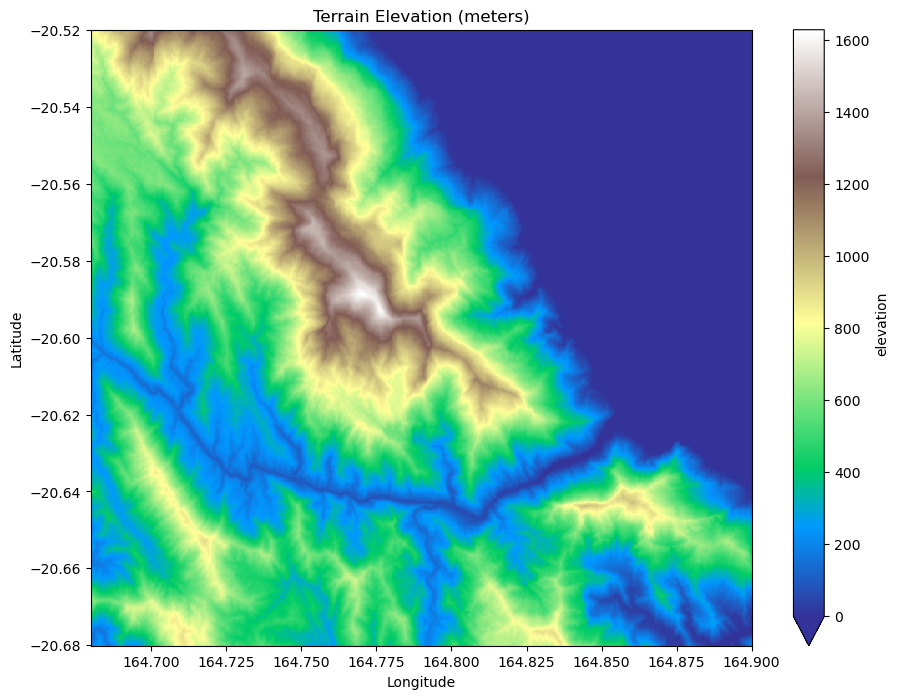

In [13]:
clipped_data.elevation.plot.imshow(size=8,cmap=plt.cm.terrain,vmin=0.0,vmax=np.max(clipped_data.elevation))
plt.title('Terrain Elevation (meters)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Save the output data in a GeoTIFF file

In [14]:
filename = "DEM_sample.tiff"

In [16]:
# Set the dimensions of file in pixels
height = clipped_data.elevation.shape[0]
width = clipped_data.elevation.shape[1]

In [18]:
# Define the Coordinate Reference System (CRS) to be common Lat-Lon coordinates
# Define the tranformation using our bounding box so the Lat-Lon information is written to the GeoTIFF
gt = rasterio.transform.from_bounds(ll[0],ur[0],ll[1],ur[1],width,height)
clipped_data.rio.write_crs("epsg:4326", inplace=True)
clipped_data.rio.write_transform(transform=gt, inplace=True);

In [23]:
# Create the GeoTIFF output file using the defined parameters
with rasterio.open(filename,'w',driver='GTiff',width=width,height=height,crs='epsg:4326',
                   transform=gt,count=1,compress='lzw',dtype='float32') as dst:
    dst.write(clipped_data.elevation,1)
    dst.close()

In [24]:
# Show the location and size of the new output file
!ls *.tiff

DEM_sample.tiff
